<a href="https://colab.research.google.com/github/Mahamadou-M-Traore/Healthy-Lifestyle-RNN/blob/main/Healthy_Lifestyle_Detection_using_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_4 (SimpleRNN)        │ (None, 5, 32)          │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_5 (SimpleRNN)        │ (None, 16)             │           784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,017 (7.88 KB)

 Trainable params: 2,017 (7.88 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.5900 - loss: 0.6052 - val_accuracy: 0.8125 - val_loss: 0.4581
Epoch 2/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8104 - loss: 0.4567 - val_accuracy: 0.8138 - val_loss: 0.4201
Epoch 3/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8014 - loss: 0.4292 - val_accuracy: 0.8138 - val_loss: 0.4013
Epoch 4/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8181 - loss: 0.3819 - val_accuracy: 0.8188 - val_loss: 0.3927
Epoch 5/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8133 - loss: 0.3643 - val_accuracy: 0.8325 - val_loss: 0.3400
Epoch 6/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8159 - loss: 0.3471 - val_accuracy: 0.8388 - val_loss: 0.3317
Epoch 7/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8226 - loss: 0.3345 - val_accuracy: 0.8500 - val_loss: 0.3171
Epoch 8/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8428 - loss: 0.3222 - val_accura

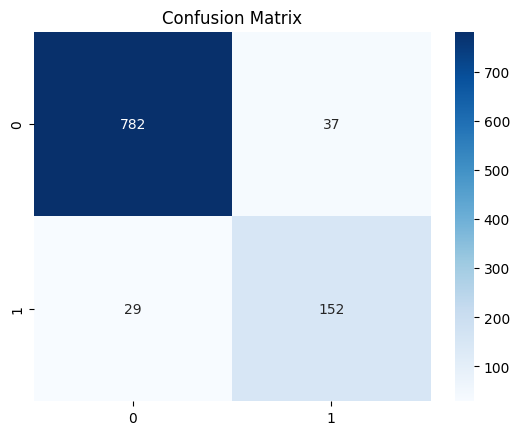

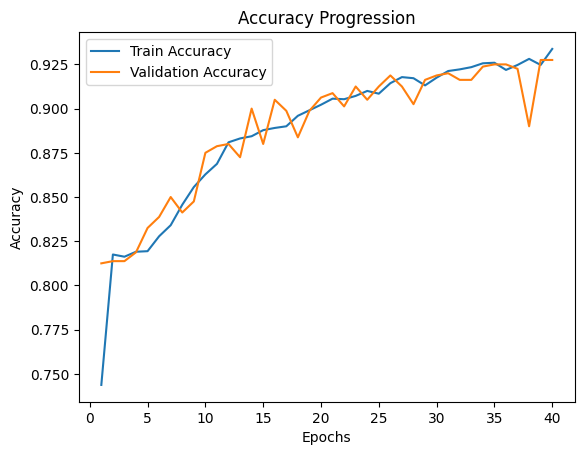

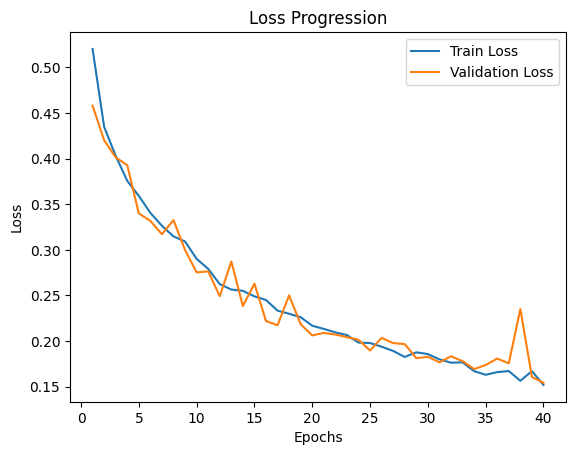

In [3]:
#    Healthy Lifestyle Detection using RNN

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from tensorflow.keras.layers import Input
from tensorflow.keras.optimizers import Adam

#   Generate synthetic data
np.random.seed(42)
data_size = 5000

sleep_hours = np.random.normal(7, 1.5, data_size).clip(3, 12)
calorie_intake = np.random.normal(2200, 400, data_size).clip(1000, 4000)
exercise_minutes = np.random.normal(35, 20, data_size).clip(0, 120)
water_liters = np.random.normal(2, 0.6, data_size).clip(0.5, 4)
steps_count = np.random.normal(8000, 3000, data_size).clip(500, 20000)

#   Label generation (Healthy = 1 / Unhealthy = 0)
healthy_label = (
    (sleep_hours >= 6) & (sleep_hours <= 9) &
    (1600 <= calorie_intake) & (calorie_intake <= 2600) &
    (exercise_minutes >= 30) &
    (water_liters >= 1.5) &
    (steps_count >= 6000)
).astype(int)

df = pd.DataFrame({
    "sleep_hours": sleep_hours,
    "calorie_intake": calorie_intake,
    "exercise_minutes": exercise_minutes,
    "water_liters": water_liters,
    "steps_count": steps_count,
    "healthy_lifestyle": healthy_label
})

df.to_csv("healthy_lifestyle_dataset.csv", index=False)


#    DATA PREPROCESSING & NORMALIZATION


data = pd.read_csv("healthy_lifestyle_dataset.csv")

X = data.drop("healthy_lifestyle", axis=1).values
y = data["healthy_lifestyle"].values

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

#     RNN expects sequential shape (samples, time_steps, features)
X_scaled = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


#    RNN MODEL DEVELOPMENT  (Model Creation)


model = Sequential([
    Input(shape=(5, 1)),
    SimpleRNN(32, return_sequences=True),
    SimpleRNN(16),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print(model.summary())



#    MODEL TRAINING & EVALUATION


history = model.fit(
    X_train, y_train,
    epochs=40,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

loss, acc = model.evaluate(X_test, y_test)
print(f"\n🔥 Test Accuracy = {acc*100:.2f}%")

y_pred = (model.predict(X_test) > 0.5).astype(int)

print("\n📌 Classification Report:\n", classification_report(y_test, y_pred))


acc = history.history['accuracy']
val_acc = history.history['val_accuracy']


#   Model starts stabilizing around epoch
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

for i in range(2, len(acc)):
    if abs(acc[i] - acc[i-1]) < 0.001 and abs(val_acc[i] - val_acc[i-1]) < 0.001:
        print(f"Model may be stable starting around epoch {i+1}")
        break


                      #VISUAL PERFORMANCE ANALYSIS


#   Confusion matrix + Accuracy/Loss graphs


cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

epochs = range(1, len(history.history['accuracy'])+1)

plt.plot(epochs, history.history['accuracy'], label="Train Accuracy")
plt.plot(epochs, history.history['val_accuracy'], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Progression")
plt.legend()
plt.show()

plt.plot(epochs, history.history['loss'], label="Train Loss")
plt.plot(epochs, history.history['val_loss'], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Progression")
plt.legend()
plt.show()

